In [1]:
import sys, importlib
MODULE_DIR = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/review_analysis/script"
if MODULE_DIR not in sys.path:
    sys.path.insert(0, MODULE_DIR)

import regional_plot_tools
importlib.reload(regional_plot_tools)

<module 'regional_plot_tools' from '/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/review_analysis/script/regional_plot_tools.py'>

In [2]:
# 提取TEST列包含'ADD'的ID形成list
import ast
import pandas as pd

gwas_path = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/analysis/assoc_plink2/results/02.summary_vis/gwas_summary.plink2.csv"

gwas_df = pd.read_csv(gwas_path)

# 解析字符串为列表后检查
def contains_add(test_str):
    try:
        test_list = ast.literal_eval(test_str)
        return 'ADD' in test_list
    except:
        return False

variant_ids_method = gwas_df[gwas_df['TEST'].apply(contains_add)]['ID'].tolist()
variant_ids = variant_ids_method

print(f"包含'ADD'的变异ID数量: {len(variant_ids)}")
print(f"变异ID列表: {variant_ids}")

包含'ADD'的变异ID数量: 5
变异ID列表: ['chr3:154069965:A:G', 'chr16:53884344:G:A', 'chr16:53887925:T:C', 'chr17:13528059:G:A', 'chr17:13528180:G:A']


In [3]:
bed_prefix = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/wgs/19.tommo_panel_filter/cteph_agp3k.lowfreq_common"

In [ ]:
# from regional_plot_tools import plink_to_vcf_raw

# vcf_path = plink_to_vcf_raw(
#     bed_prefix=bed_prefix,         
#     plink_path="/home/b/b37974/plink",
#     bcftools_path="/home/b/b37974/bcftools/bcftools",
#     ref_fa="/LARGE0/gr10478/b37974/Pulmonary_Hypertension/nagasaki_pipeline/data/hs38DH.fa",
#     rename_chr="/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/info/rename_chr.txt",
#     threads=6,
#     delete_tmp=False                      
# )
# print(vcf_path)

[信息] 正在用 plink (1.9) 导出 bgzip 压缩 VCF（.vcf.gz，样本名为 IID）…
[信息] 正在用 bcftools 为初始 .vcf.gz 建立 tbi 索引…
[信息] 检测到 rename_chr 文件，正在用 bcftools annotate --rename-chrs 进行染色体重命名，映射文件：/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/info/rename_chr.txt
[信息] 正在为重命名后的 VCF 建立 tbi 索引…
[信息] 已应用染色体重命名，使用映射文件：/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/info/rename_chr.txt
[信息] 正在用 bcftools norm 进行规范化（--multiallelics -any, --check-ref s）…
[信息] 正在用 bcftools 为规范化后的 .vcf.gz 建立 tbi 索引…
[完成] 生成规范化后的压缩 VCF：/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/review_analysis/04.regional_plot/tmp/cteph_agp3k.lowfreq_common.norm.vcf.gz
[完成] 生成规范化后的索引：/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/review_analysis/04.regional_plot/tmp/cteph_agp3k.lowfreq_common.norm.vcf.gz.tbi
/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/review_analysis/04.regional_plot/tmp/cteph_agp3k.lowfreq_common.norm.vcf.gz


In [ ]:
vcf_path = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/review_analysis/04.regional_plot/tmp/cteph_agp3k.lowfreq_common.norm.vcf.gz"

In [6]:
import pandas as pd
import numpy as np
import gwaslab as gl
import logging
import matplotlib.pyplot as plt

plt.style.use('default')

# 屏蔽 matplotlib 的 log
logging.getLogger("matplotlib").setLevel(logging.ERROR)

# # 屏蔽 gwaslab 的 log
# logging.getLogger("gwaslab").setLevel(logging.CRITICAL)
# logging.getLogger("GWASLab").setLevel(logging.CRITICAL)
# logging.getLogger("gl").setLevel(logging.CRITICAL)

sig_level = 5e-8

add_tag = "additive"
dom_tag = "dominant"
rec_tag = "recessive"

add_path = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/analysis/assoc_plink2/results/01.assoc_result/additive/cteph_agp3k.sex.10pc.additive.PHENO1.glm.logistic"
# dom_path = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/analysis/assoc_plink2/results/01.assoc_result/dominant/cteph_agp3k.sex.10pc.dominant.PHENO1.glm.logistic"
# rec_path = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/analysis/assoc_plink2/results/01.assoc_result/recessive/cteph_agp3k.sex.10pc.recessive.PHENO1.glm.logistic"

In [7]:
sumstats_add = gl.Sumstats(add_path, fmt="plink2", build='38', ea='A1', nea='OMITTED', OR_95L='L95', OR_95U='U95')
# sumstats_dom = gl.Sumstats(dom_path, fmt="plink2", build='38', ea='A1', nea='OMITTED', OR_95L='L95', OR_95U='U95')
# sumstats_rec = gl.Sumstats(rec_path, fmt="plink2", build='38', ea='A1', nea='OMITTED', OR_95L='L95', OR_95U='U95')

2025/10/08 11:21:14 GWASLab v3.6.0 https://cloufield.github.io/gwaslab/
2025/10/08 11:21:14 (C) 2022-2025, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2025/10/08 11:21:14 Python version: 3.9.21 | packaged by conda-forge | (main, Dec  5 2024, 13:51:40) 
[GCC 13.3.0]
2025/10/08 11:21:14 Start to load format from formatbook....
2025/10/08 11:21:14  -plink2 format meta info:
2025/10/08 11:21:14   - format_name  : PLINK2 .glm.firth, .glm.logistic,.glm.linear
2025/10/08 11:21:14   - format_source  : https://www.cog-genomics.org/plink/2.0/formats
2025/10/08 11:21:14   - format_version  : Alpha 3.3 final (3 Jun)
2025/10/08 11:21:14   - last_check_date  :  20220806
2025/10/08 11:21:14  -plink2 to gwaslab format dictionary:
2025/10/08 11:21:14   - plink2 keys: ID,#CHROM,POS,REF,ALT,A1,OBS_CT,A1_FREQ,BETA,LOG(OR)_SE,SE,T_STAT,Z_STAT,P,LOG10_P,MACH_R2,OR
2025/10/08 11:21:14   - gwaslab values: SNPID,CHR,POS,REF,ALT,EA,N,EAF,BETA,SE,SE,T,Z,P,MLOG10P,INFO,OR
2025/10/08 11:21:14 Start 

2025/10/08 11:21:22  -Reading columns          : ALT,POS,LOG(OR)_SE,P,OBS_CT,L95,#CHROM,A1,OR,Z_STAT,ID,REF,A1_FREQ,OMITTED,U95
2025/10/08 11:21:22  -Renaming columns to      : ALT,POS,SE,P,N,OR_95L,CHR,EA,OR,Z,SNPID,REF,EAF,NEA,OR_95U
2025/10/08 11:21:22  -Current Dataframe shape : 5314835  x  15
2025/10/08 11:21:22  -Initiating a status column: STATUS ...
2025/10/08 11:21:22  -Genomic coordinates are based on GRCh38/hg38...
2025/10/08 11:21:22  -EA,REF and ALT columns are available: assigning NEA...
2025/10/08 11:21:23  -For variants with EA == ALT : assigning REF to NEA ...
2025/10/08 11:21:24  -For variants with EA != ALT : assigning ALT to NEA ...
2025/10/08 11:21:25 Start to reorder the columns...v3.6.0
2025/10/08 11:21:25  -Current Dataframe shape : 5314835 x 16 ; Memory usage: 531.11 MB
2025/10/08 11:21:25  -Reordering columns to    : SNPID,CHR,POS,EA,NEA,EAF,SE,Z,P,OR,OR_95L,OR_95U,N,STATUS,REF,ALT
2025/10/08 11:21:25 Finished reordering the columns.
2025/10/08 11:21:25  -Tryi

2025/10/08 11:21:26  -Prefix for chromosomes:  chr


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_name', 'gene_biotype']


(<Figure size 3000x2000 with 4 Axes>, <gwaslab.g_Log.Log at 0x7fea45628070>)

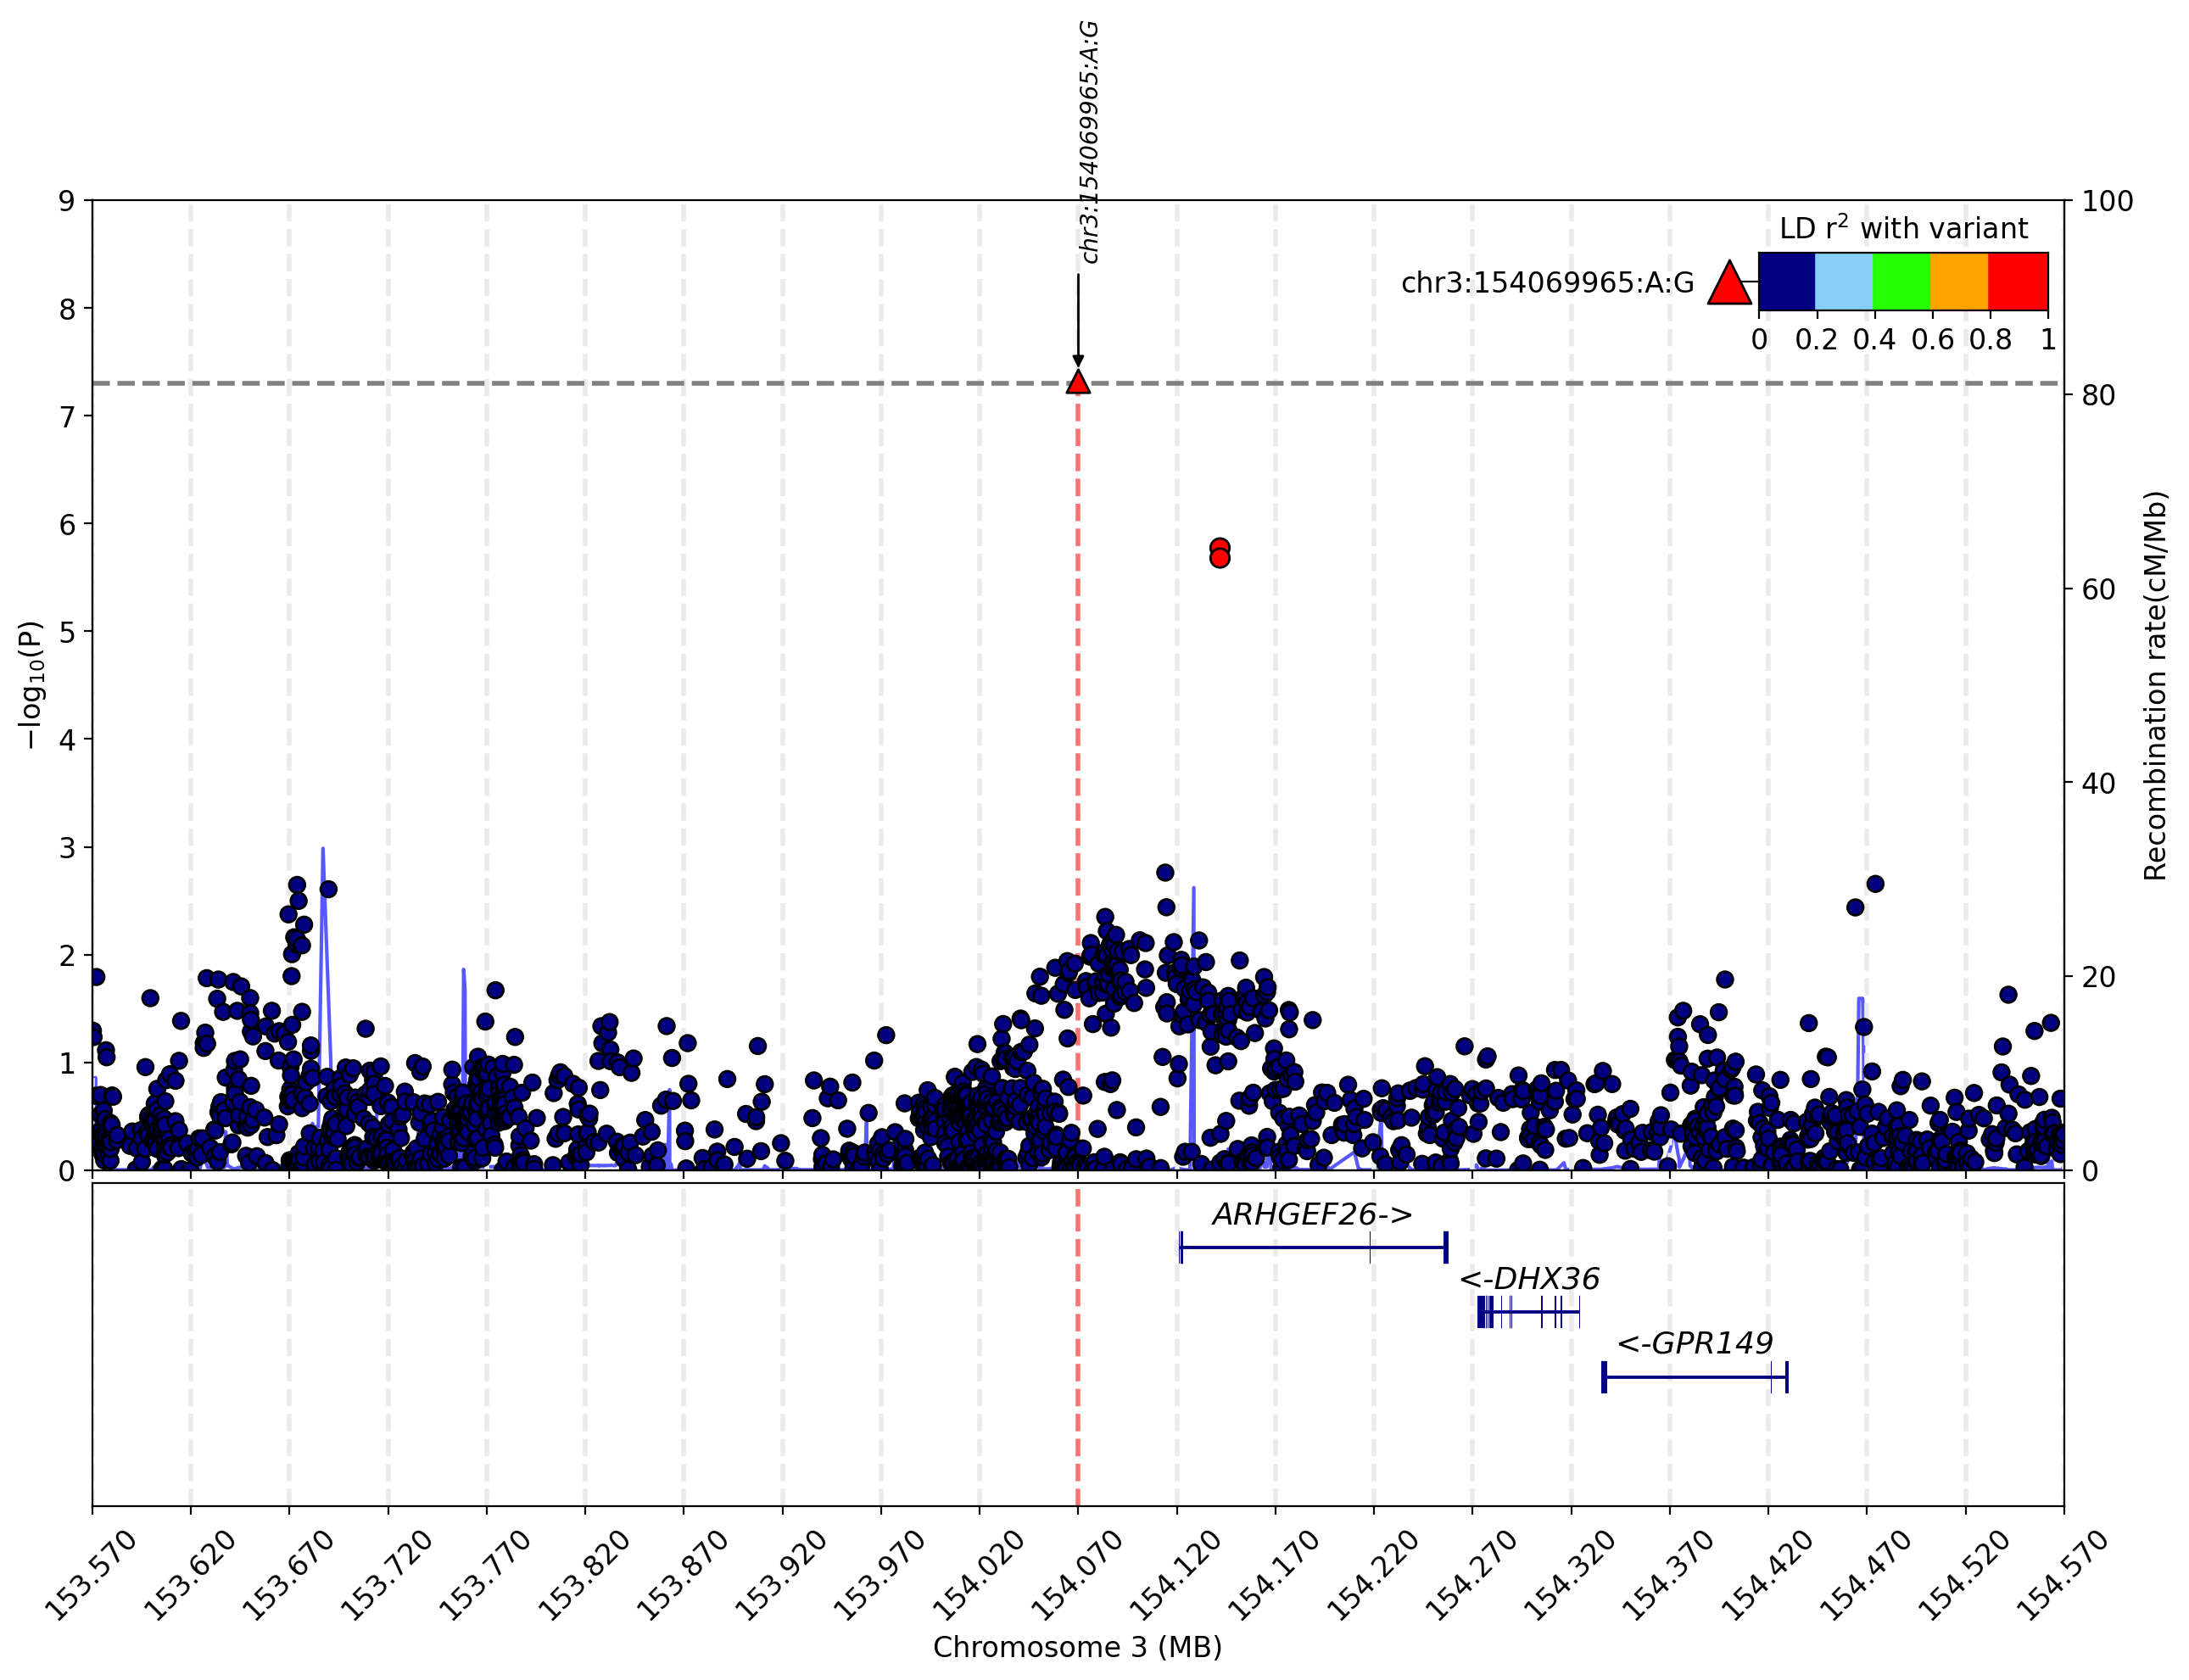

In [8]:
sumstats_add.plot_mqq(
    mode="r",
    sig_level=sig_level,
    region=(3,153569965,154569965),
    region_grid=True,
    fontsize=12,
    anno=True,
    anno_set=["chr3:154069965:A:G"],
    anno_alias={"chr3:154069965:A:G":"chr3:154069965:A:G"},
    anno_args={"fontsize":10},
    anno_style="expand",
    build="38",
    vcf_path=vcf_path,
    region_recombination=True,
    verbose=False, check=False
)

2025/10/08 11:22:16  -Prefix for chromosomes:  chr


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_name', 'gene_biotype']


(<Figure size 3000x2000 with 4 Axes>, <gwaslab.g_Log.Log at 0x7fea45628070>)

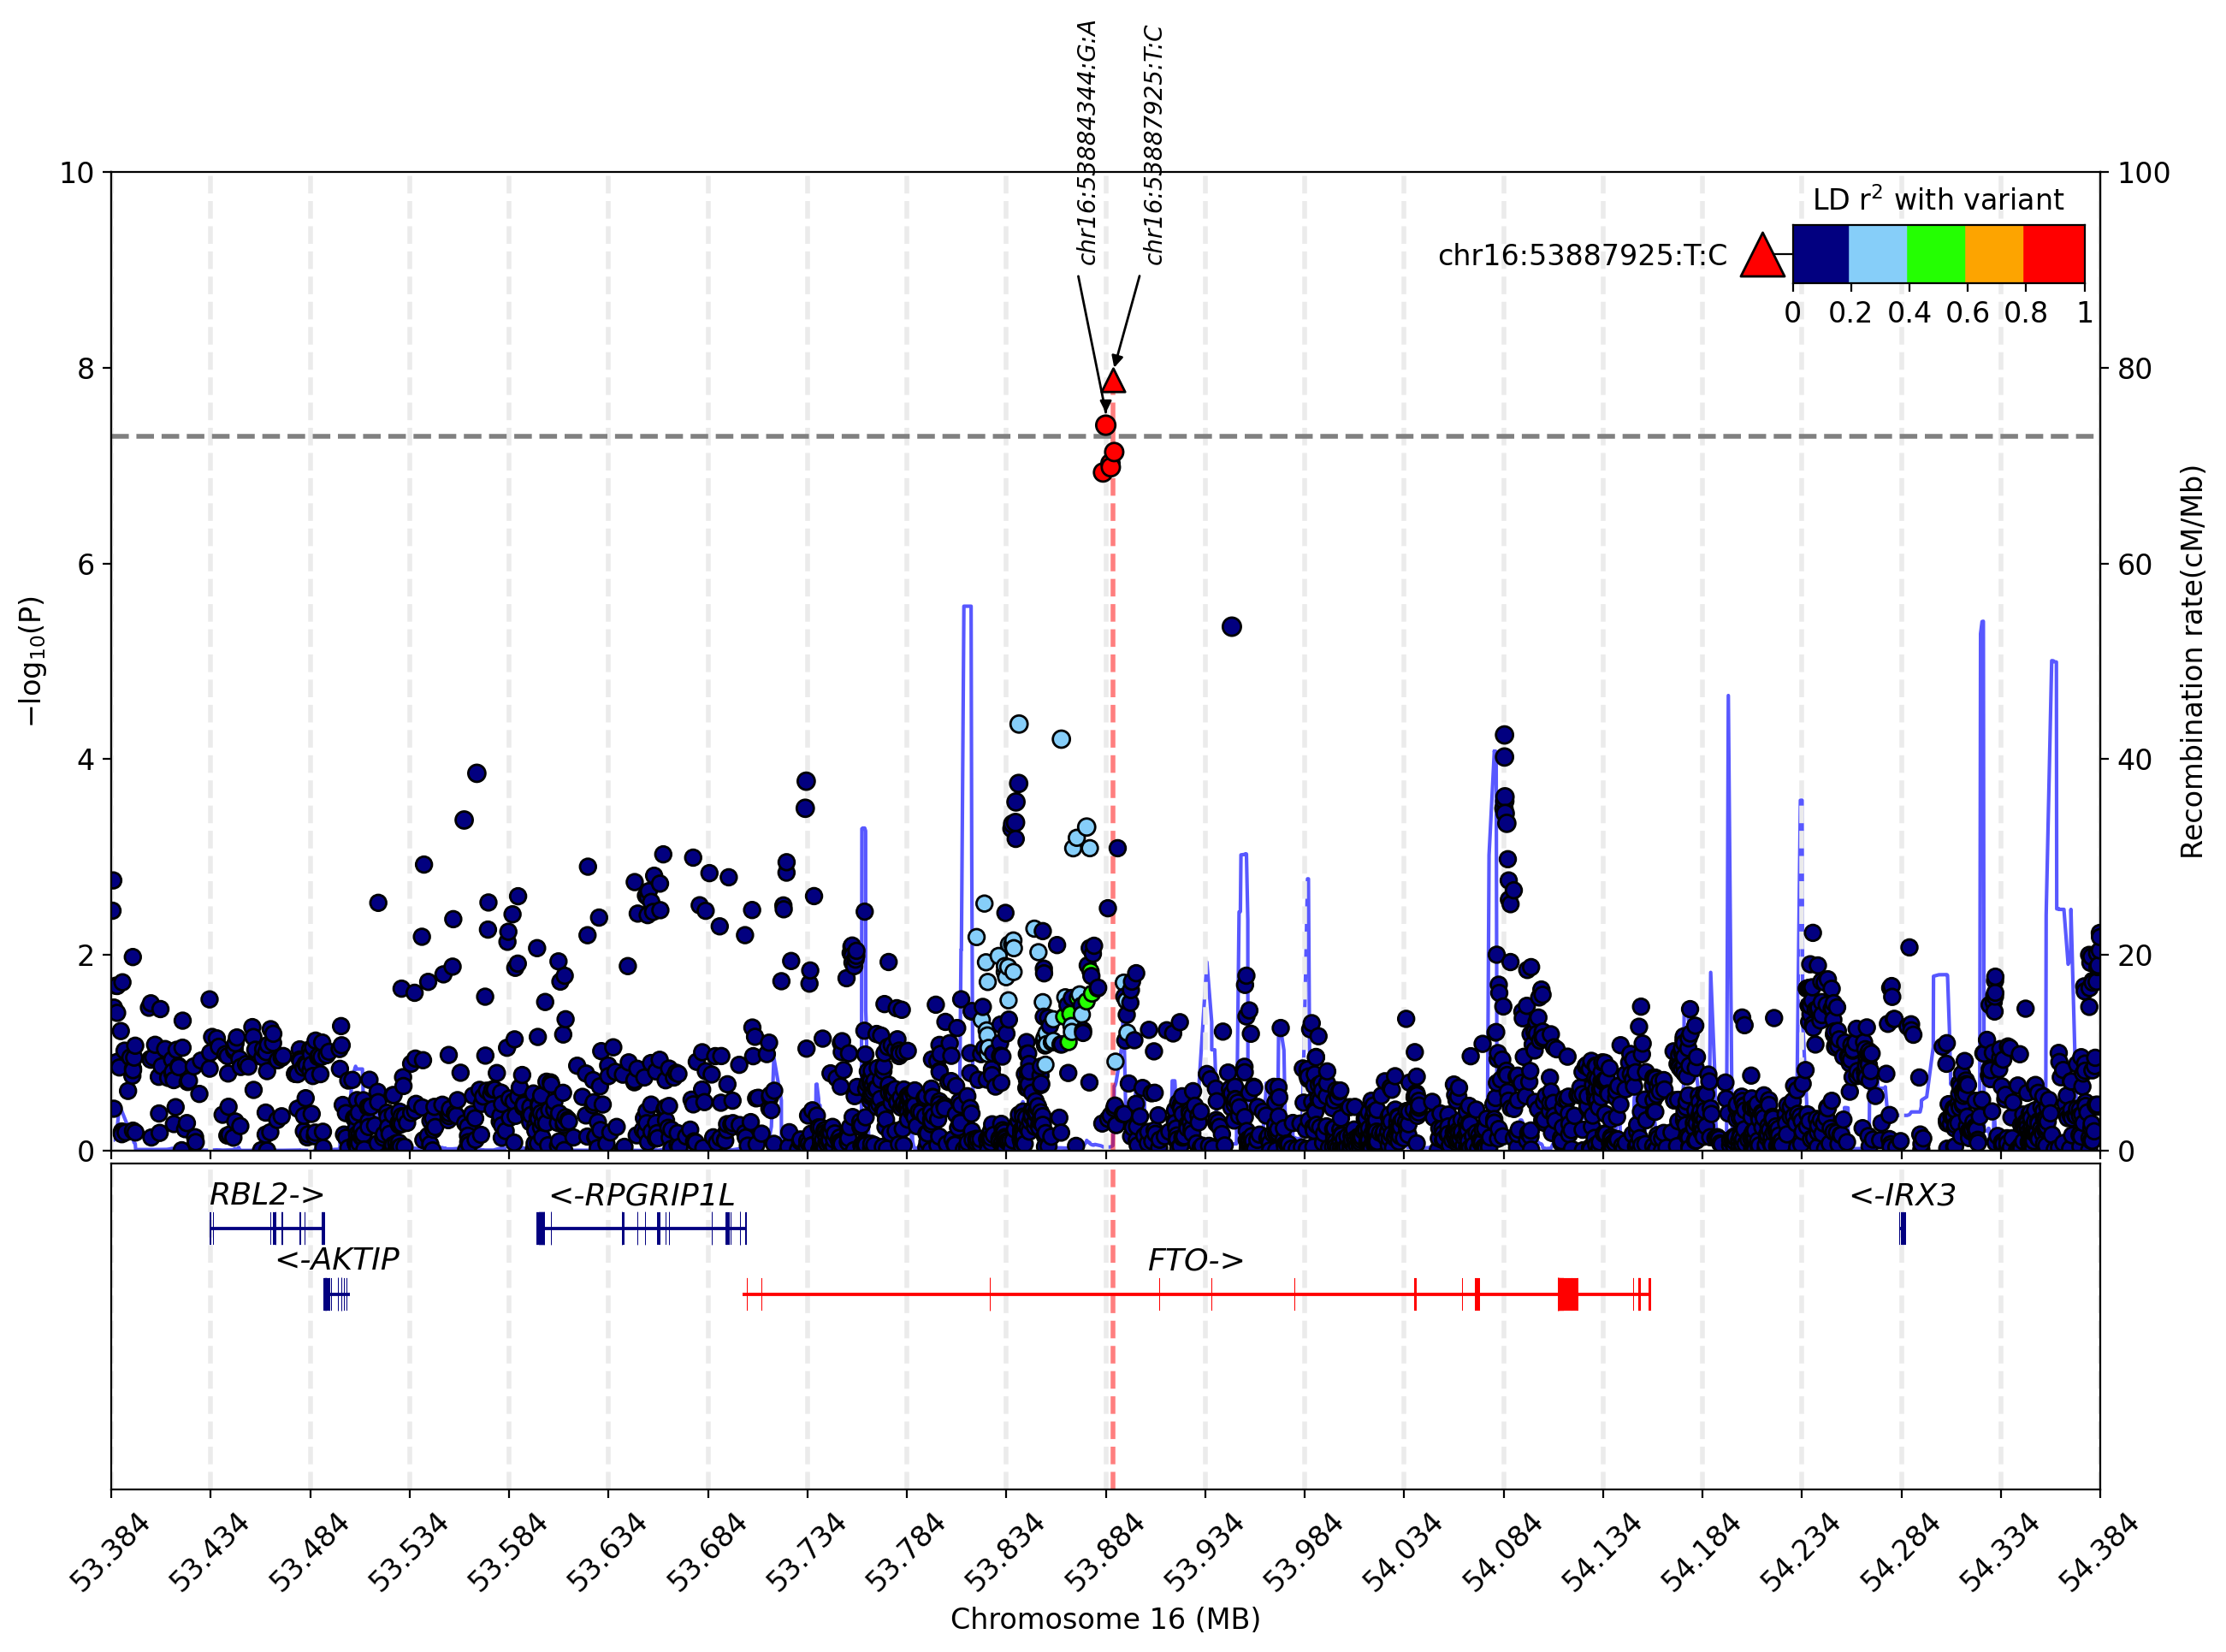

In [9]:
sumstats_add.plot_mqq(
    mode="r",
    sig_level=sig_level,
    region=(16,53384344,54384344),
    region_grid=True,
    fontsize=12,
    anno=True,
    anno_set=["chr16:53887925:T:C","chr16:53884344:G:A"],
    anno_alias={"chr16:53887925:T:C":"chr16:53887925:T:C","chr16:53884344:G:A":"chr16:53884344:G:A"},
    anno_args={"fontsize":10},
    anno_style="expand",
    build="38",
    vcf_path=vcf_path,
    region_recombination=True,
    verbose=False, check=False
)

2025/10/08 11:23:08  -Prefix for chromosomes:  chr


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_name', 'gene_biotype']


(<Figure size 3000x2000 with 4 Axes>, <gwaslab.g_Log.Log at 0x7fea45628070>)

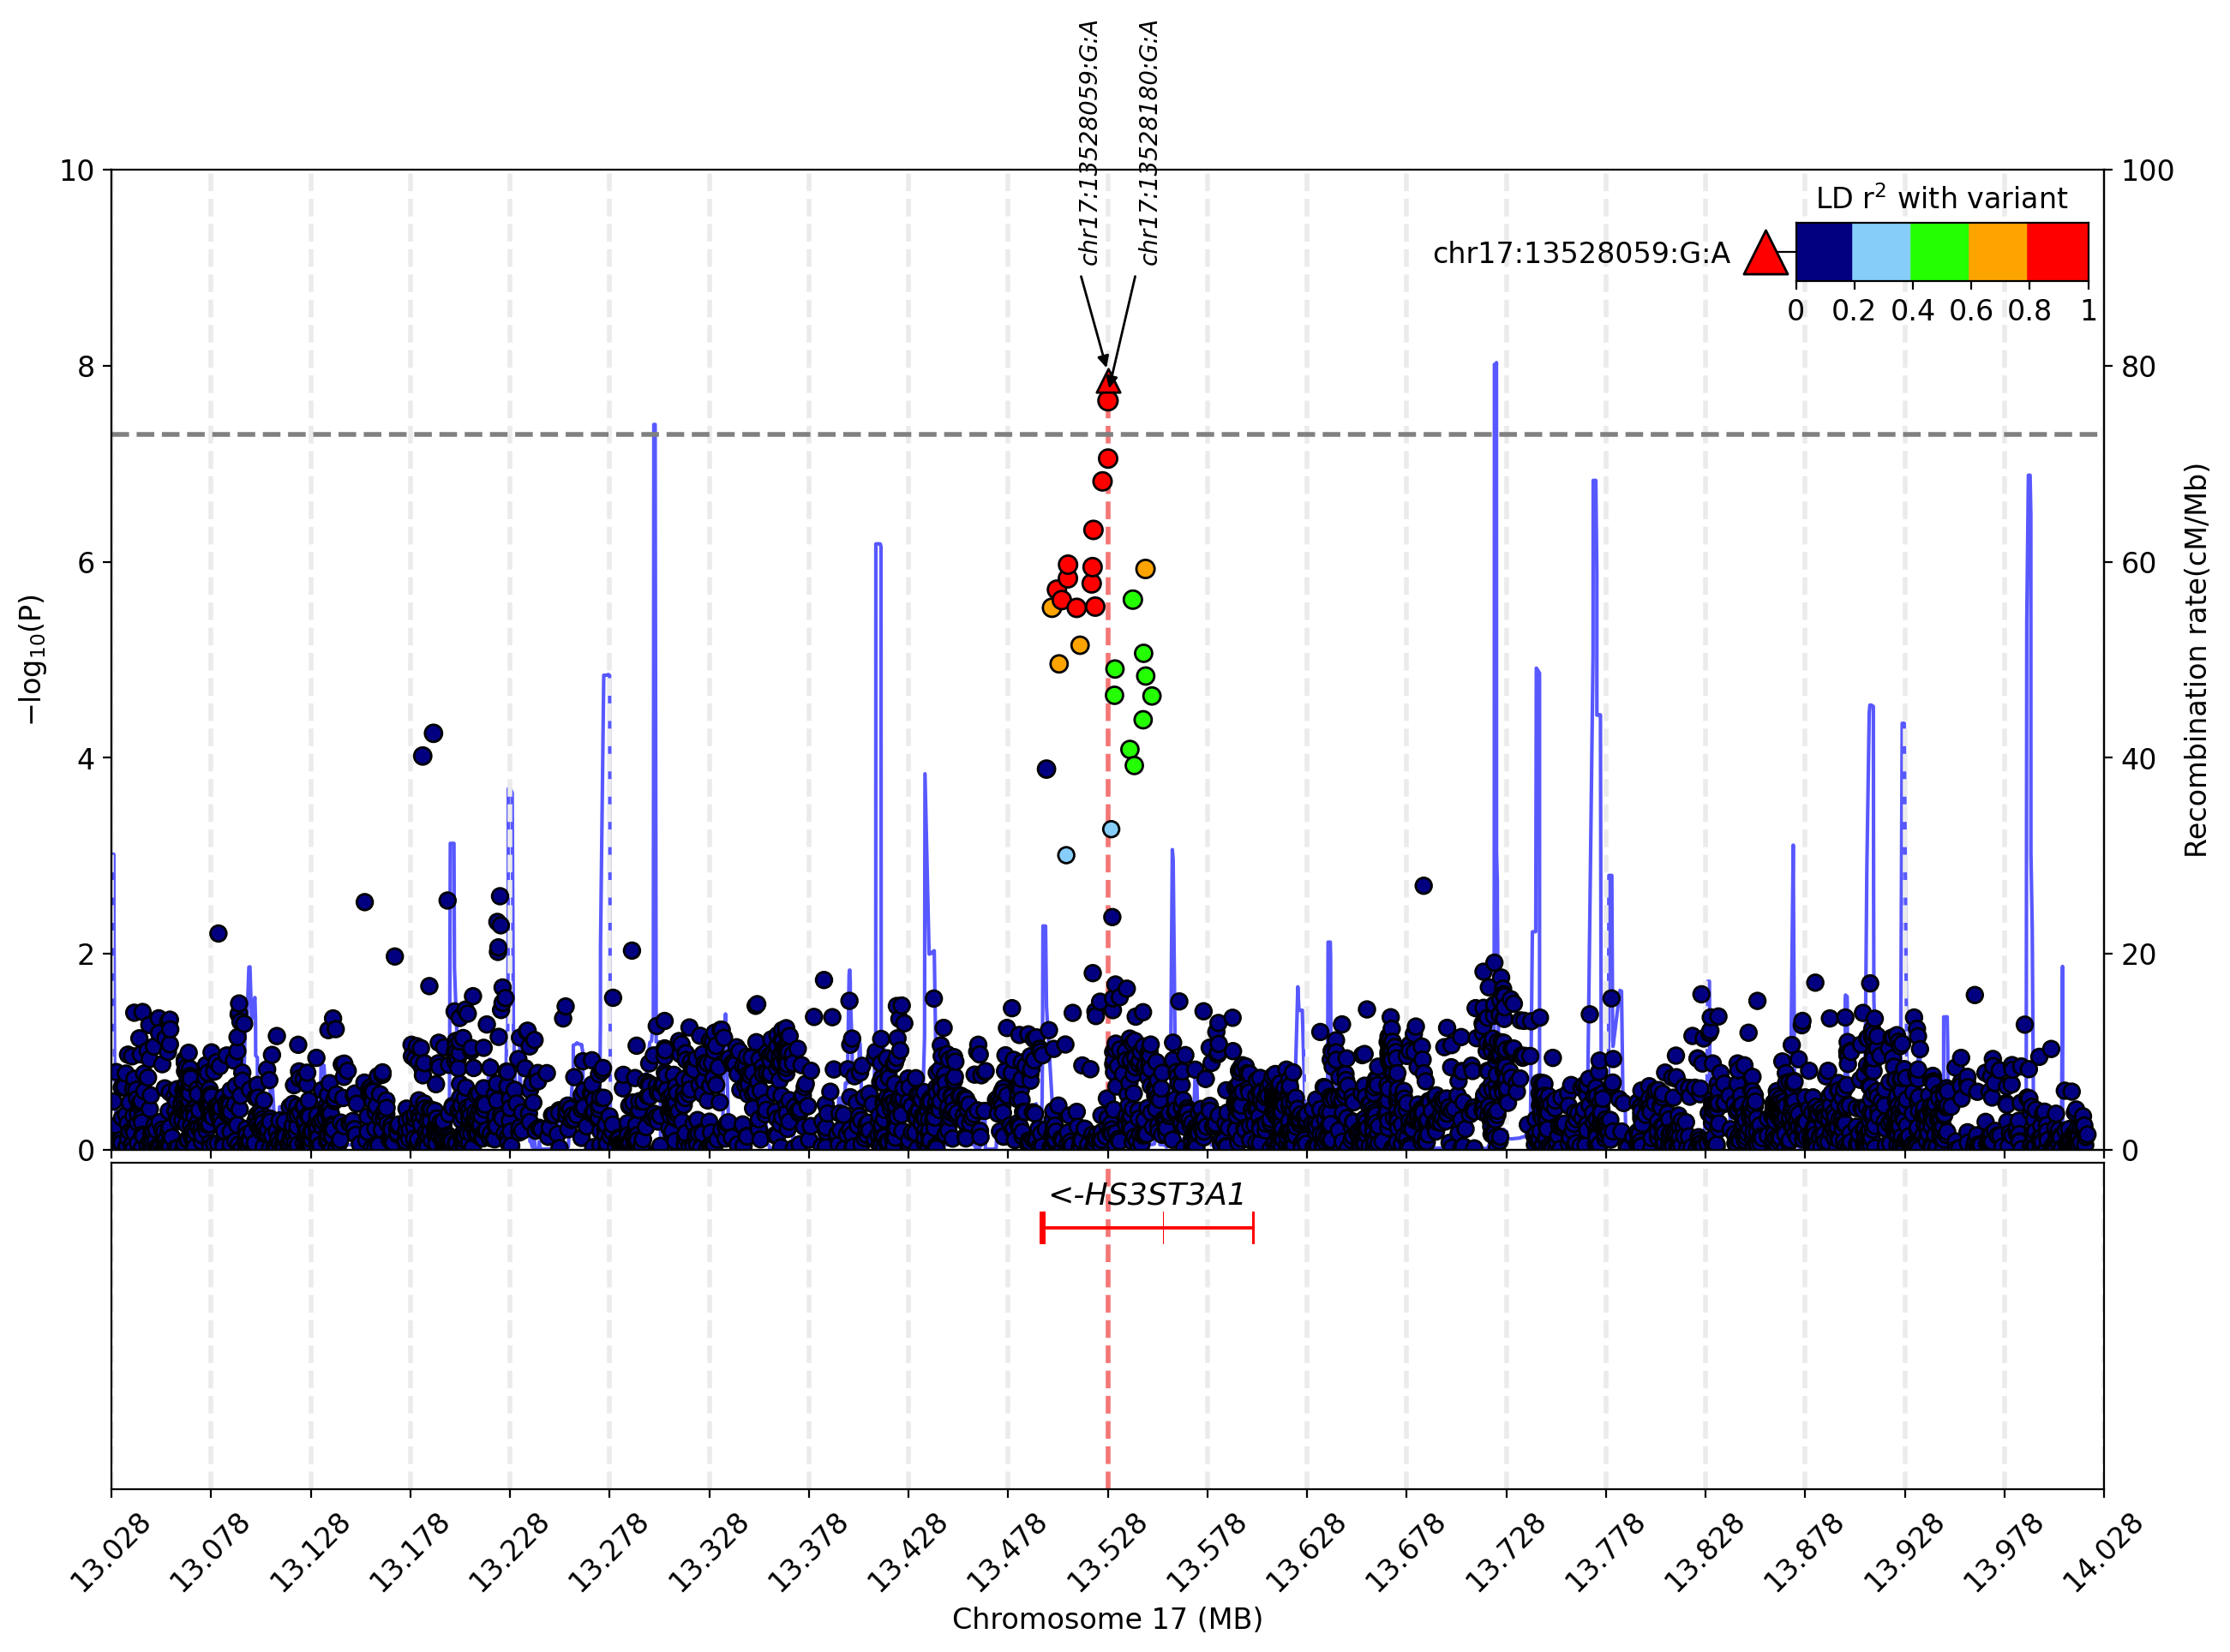

In [10]:
sumstats_add.plot_mqq(
    mode="r",
    sig_level=sig_level,
    region=(17,13028059,14028059),
    region_grid=True,
    fontsize=12,
    anno=True,
    anno_set=["chr17:13528059:G:A","chr17:13528180:G:A"],
    anno_alias={"chr17:13528059:G:A":"chr17:13528059:G:A","chr17:13528180:G:A":"chr17:13528180:G:A"},
    anno_args={"fontsize":10},
    anno_style="expand",
    build="38",
    vcf_path=vcf_path,
    region_recombination=True,
    verbose=False, check=False
)

In [11]:
eas_onekg_path = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/review_analysis/04.regional_plot/EAS.ALL.split_norm_af.1kg_30x.hg38.norm.setid.sorted.filtered.vcf.gz"

2025/10/08 11:23:59  -Prefix for chromosomes:  chr


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_name', 'gene_biotype']


2025/10/08 11:24:47  -Prefix for chromosomes:  chr


(<Figure size 3200x2400 with 6 Axes>, <gwaslab.g_Log.Log at 0x7fea3d4f05e0>)

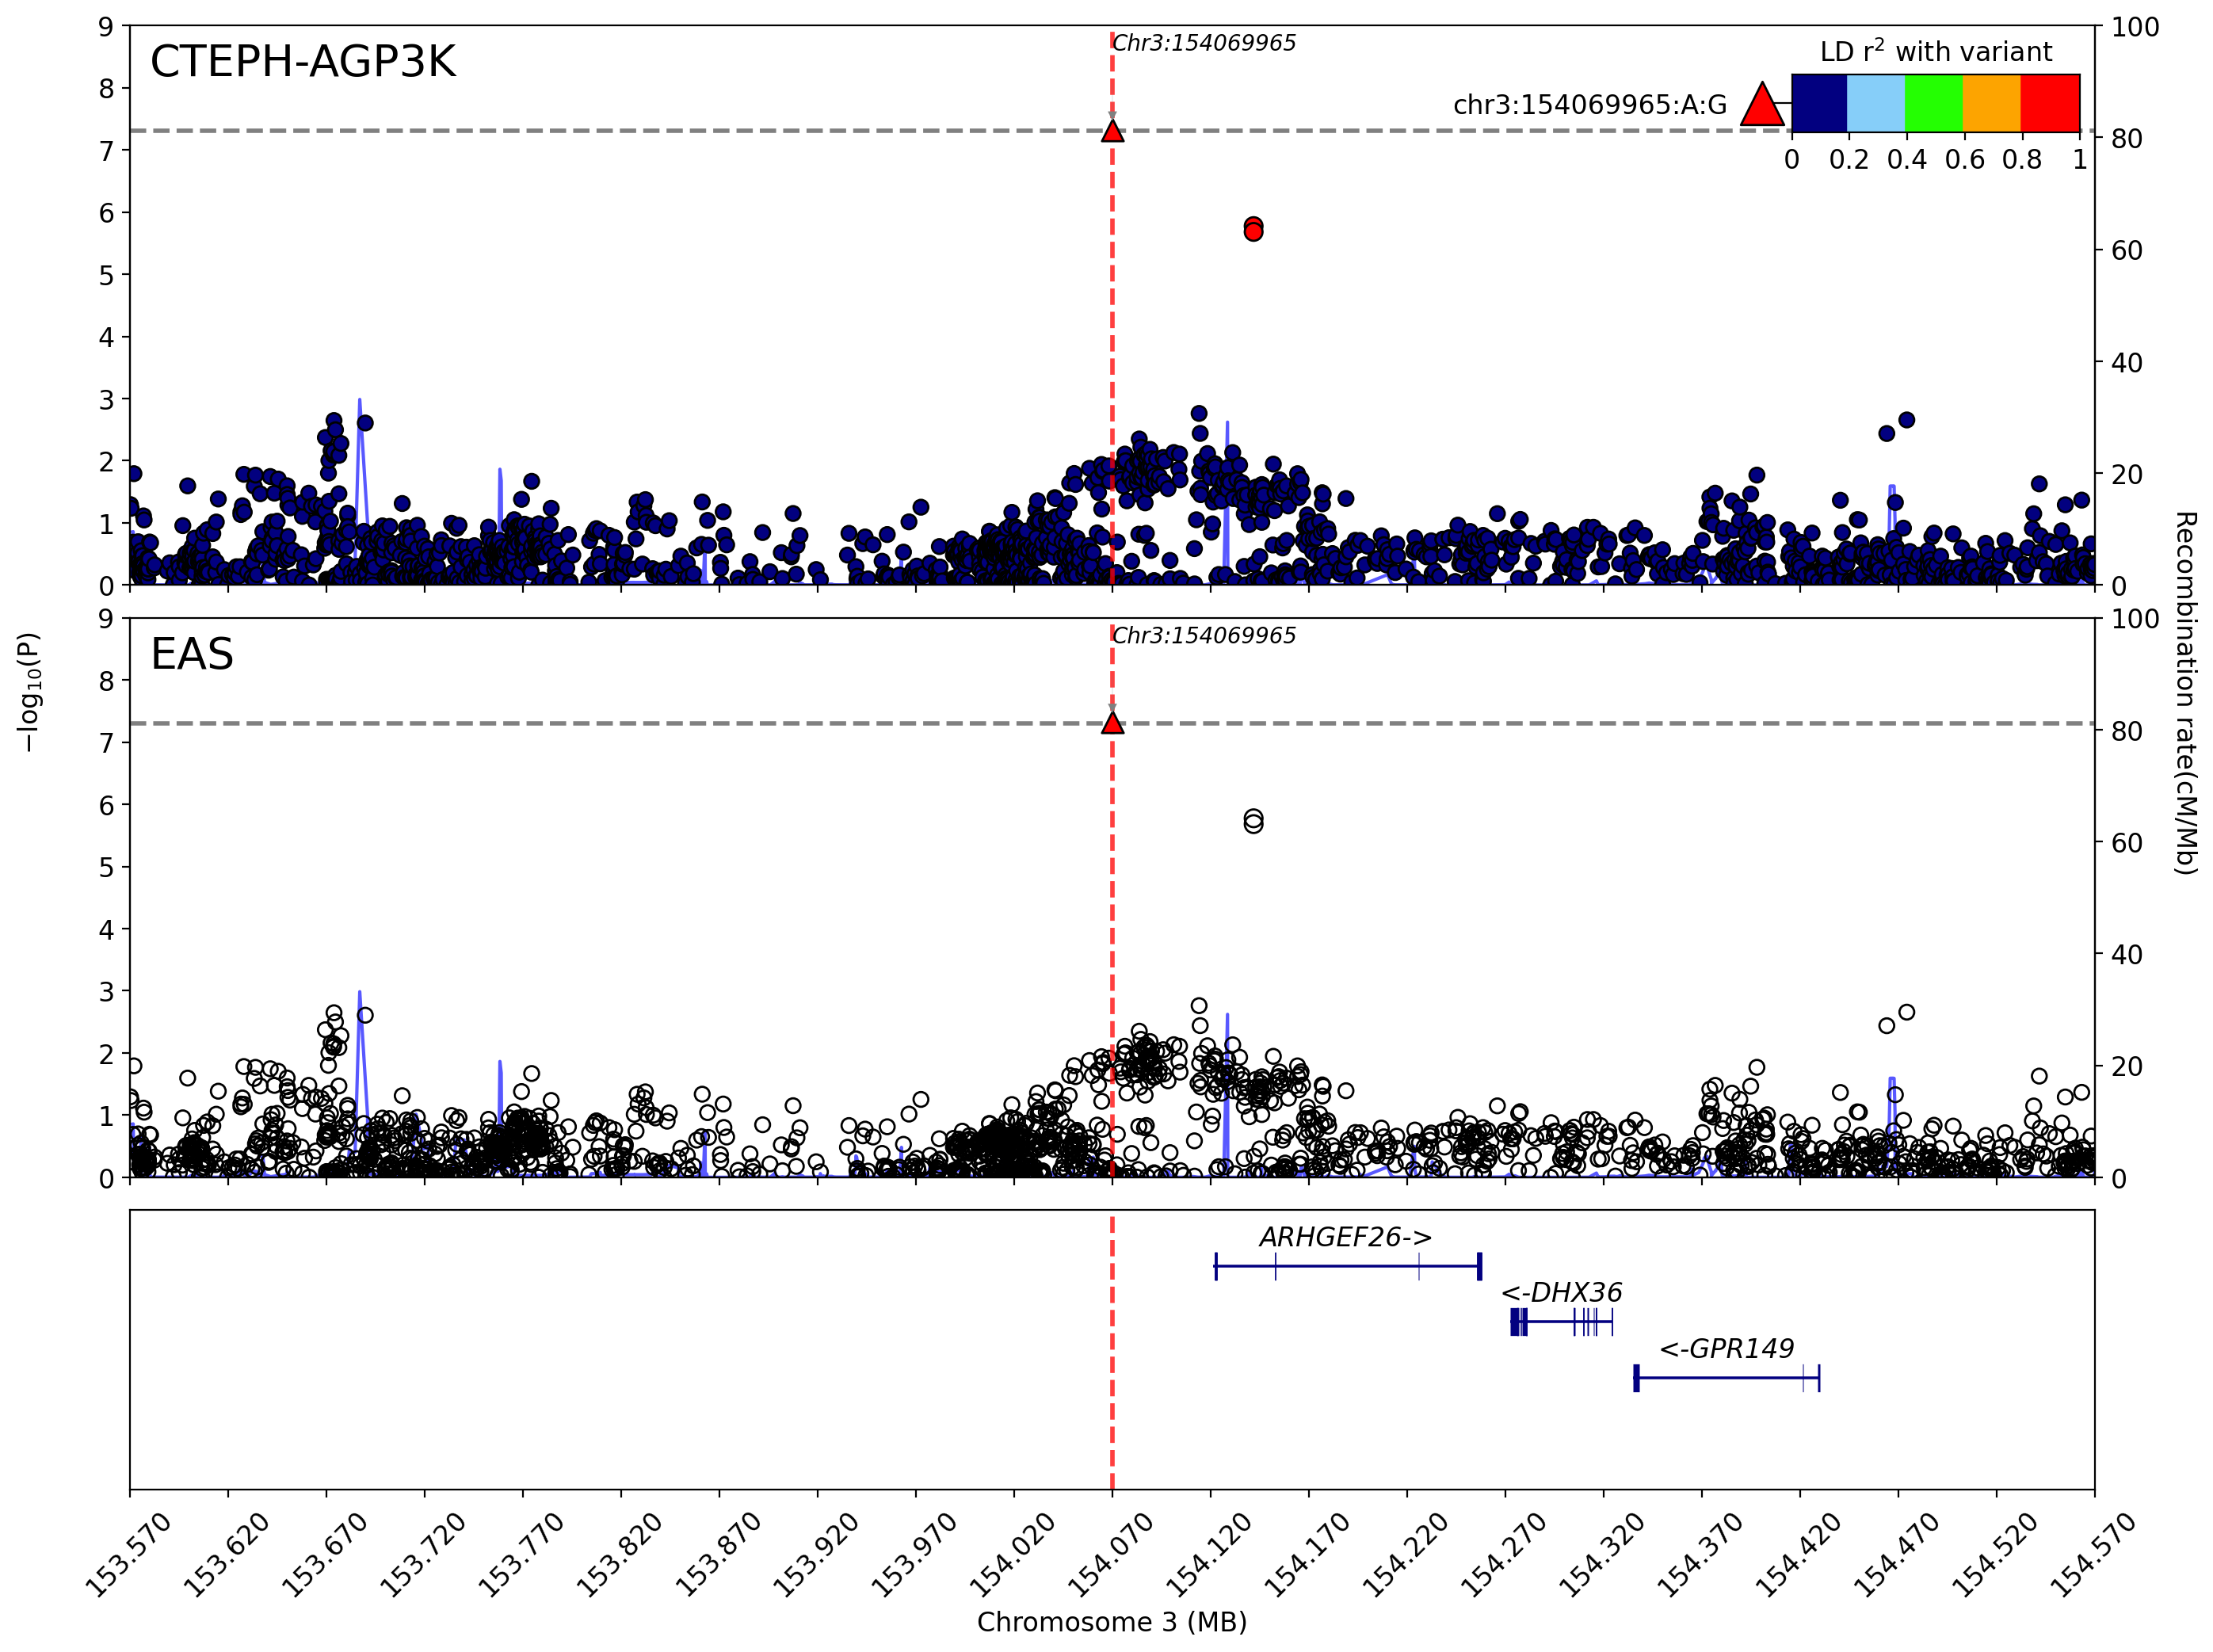

In [12]:
gl.plot_stacked_mqq(
    objects=[sumstats_add,sumstats_add],
    vcfs=[vcf_path,eas_onekg_path],
    region=(3,153569965,154569965),
    fontsize=12,
    mode="r",
    sig_level=sig_level,
    build="38",
    anno=True,
    anno_style="tight",
    anno_set=["chr3:154069965:A:G"],
    anno_args={"fontsize":10,"rotation":0},
    titles=["CTEPH-AGP3K","EAS"],
    title_args={"size":20},
    region_recombination=True,
    verbose=False, check=False
)

2025/10/08 11:24:51  -Prefix for chromosomes:  chr


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_name', 'gene_biotype']


2025/10/08 11:25:40  -Prefix for chromosomes:  chr


(<Figure size 3200x2400 with 6 Axes>, <gwaslab.g_Log.Log at 0x7fea3d4f05e0>)

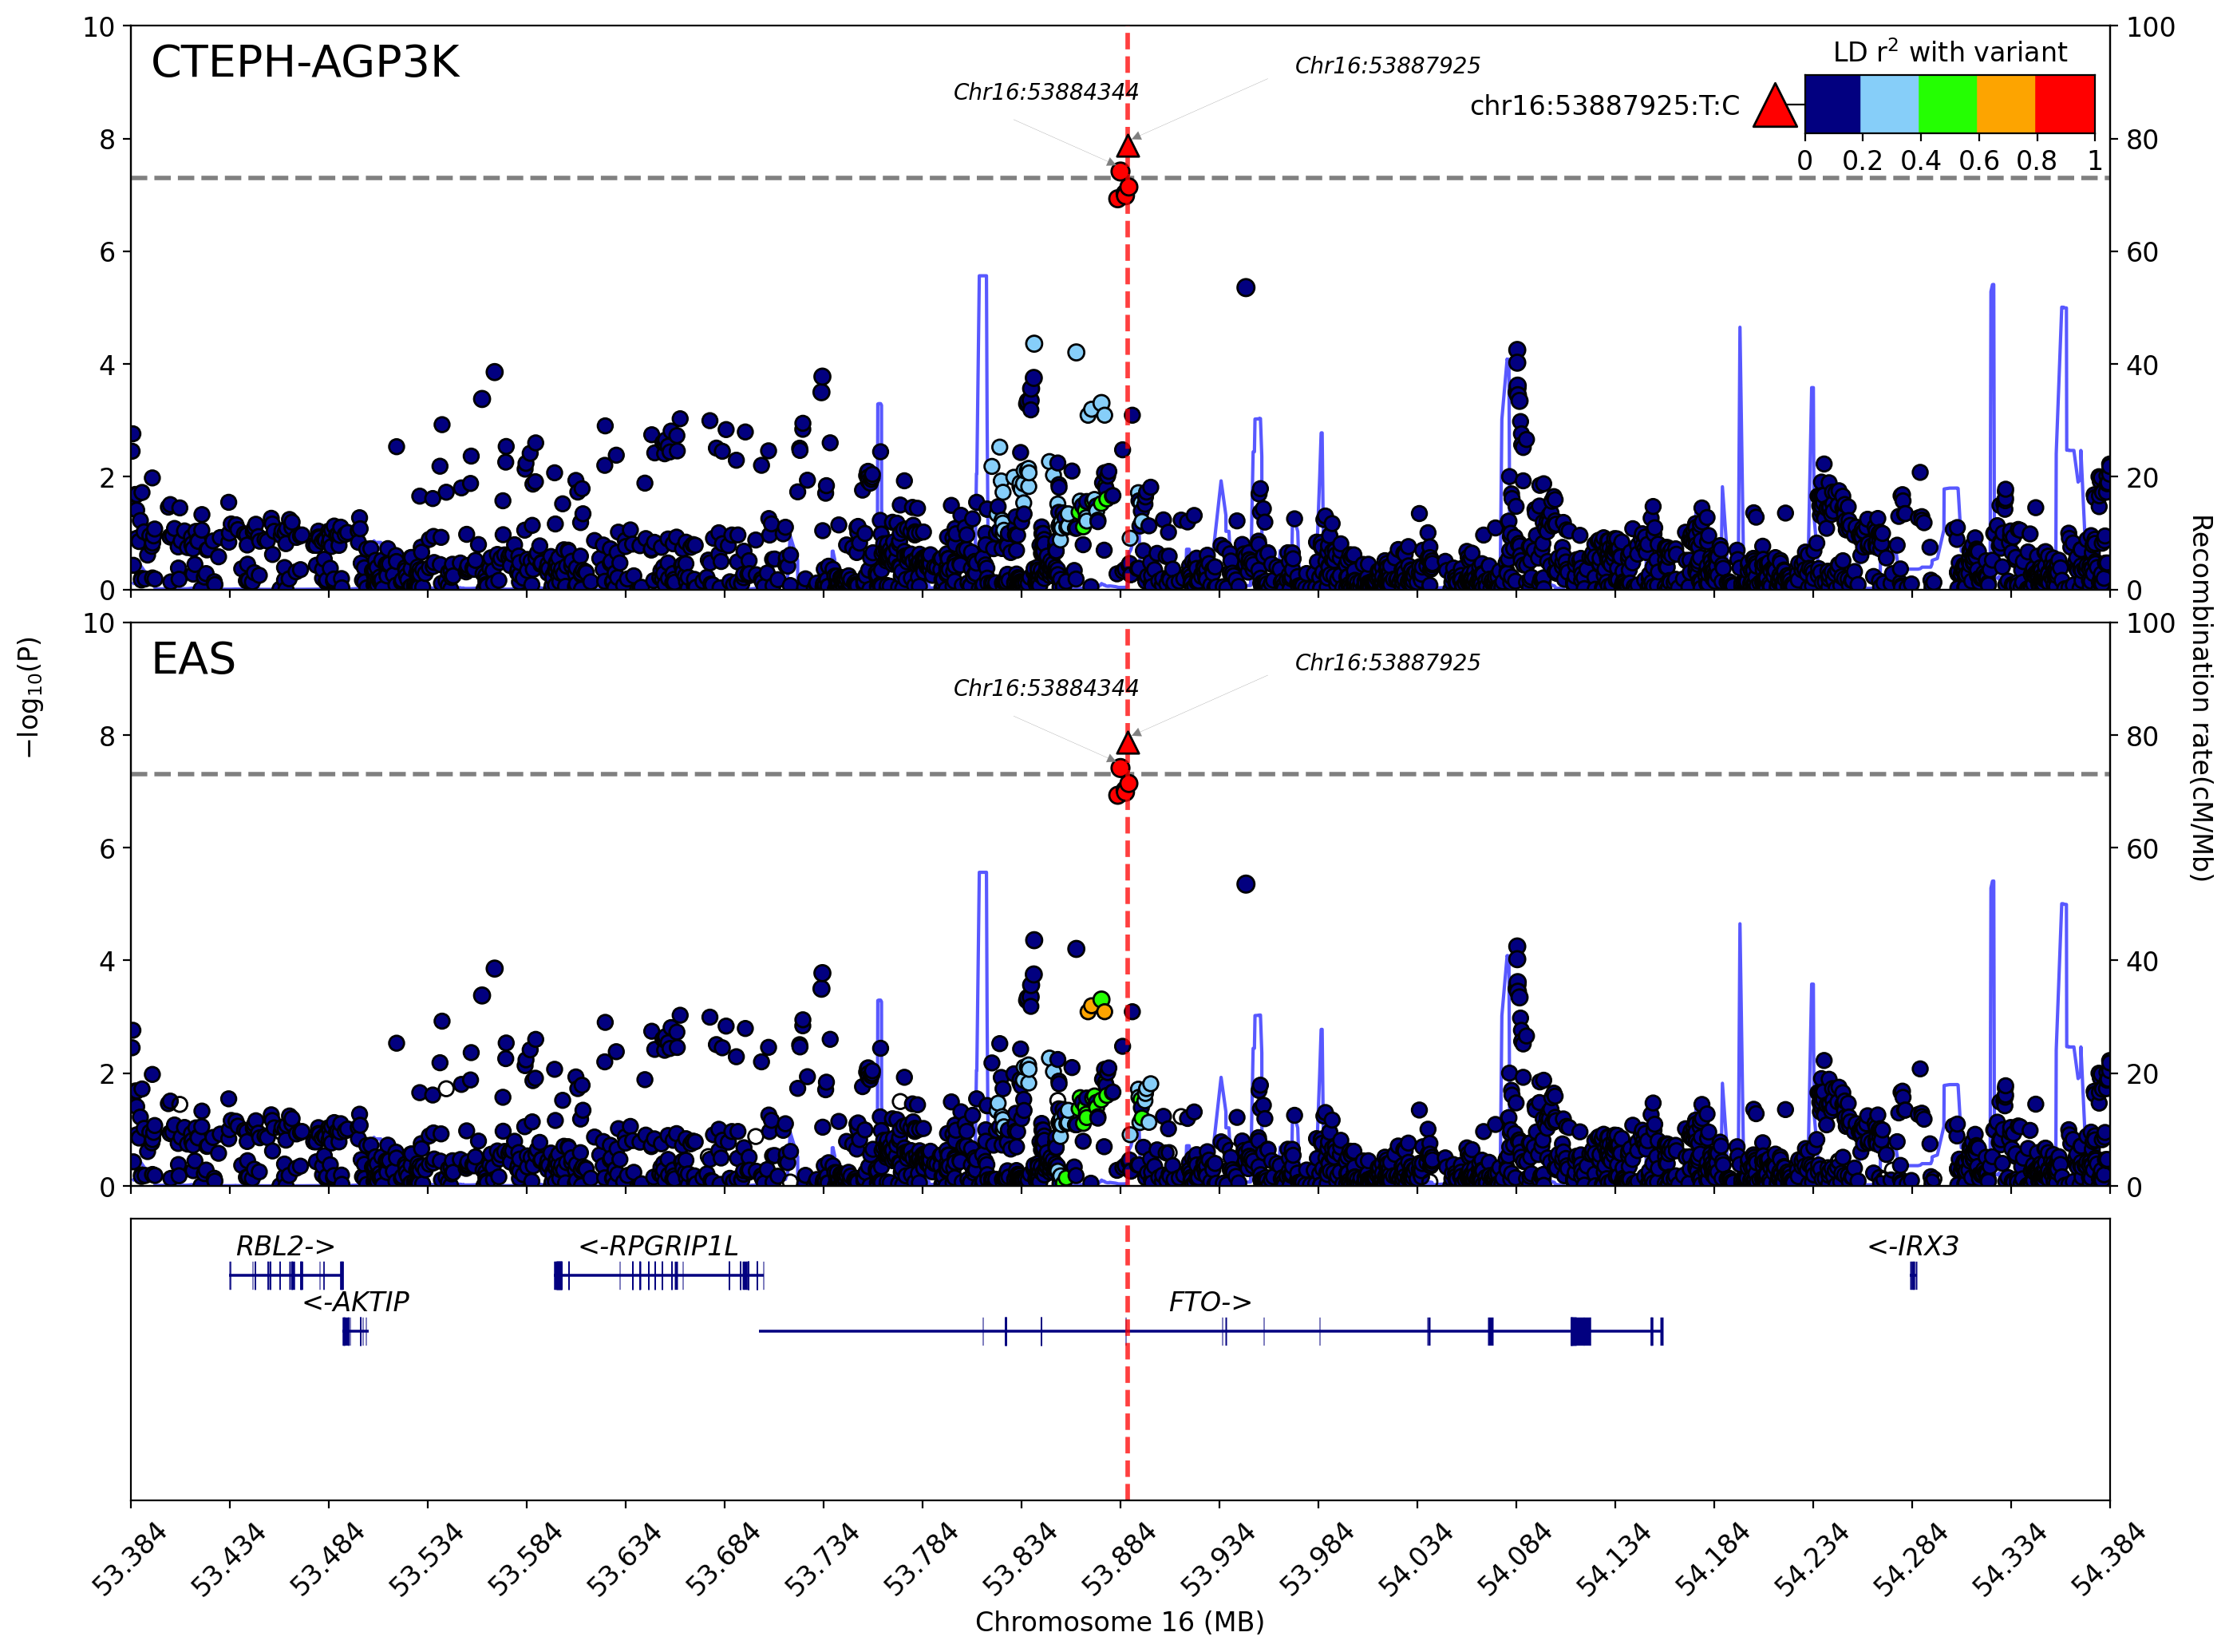

In [13]:
gl.plot_stacked_mqq(
    objects=[sumstats_add,sumstats_add],
    vcfs=[vcf_path,eas_onekg_path],
    region=(16,53384344,54384344),
    fontsize=12,
    mode="r",
    sig_level=sig_level,
    build="38",
    anno=True,
    anno_style="tight",
    anno_set=["chr16:53887925:T:C","chr16:53884344:G:A"],
    anno_args={"fontsize":10,"rotation":0},
    titles=["CTEPH-AGP3K","EAS"],
    title_args={"size":20},
    region_recombination=True,
    verbose=False, check=False
)

2025/10/08 11:25:47  -Prefix for chromosomes:  chr


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_name', 'gene_biotype']


2025/10/08 11:26:36  -Prefix for chromosomes:  chr


(<Figure size 3200x2400 with 6 Axes>, <gwaslab.g_Log.Log at 0x7fea3d4f05e0>)

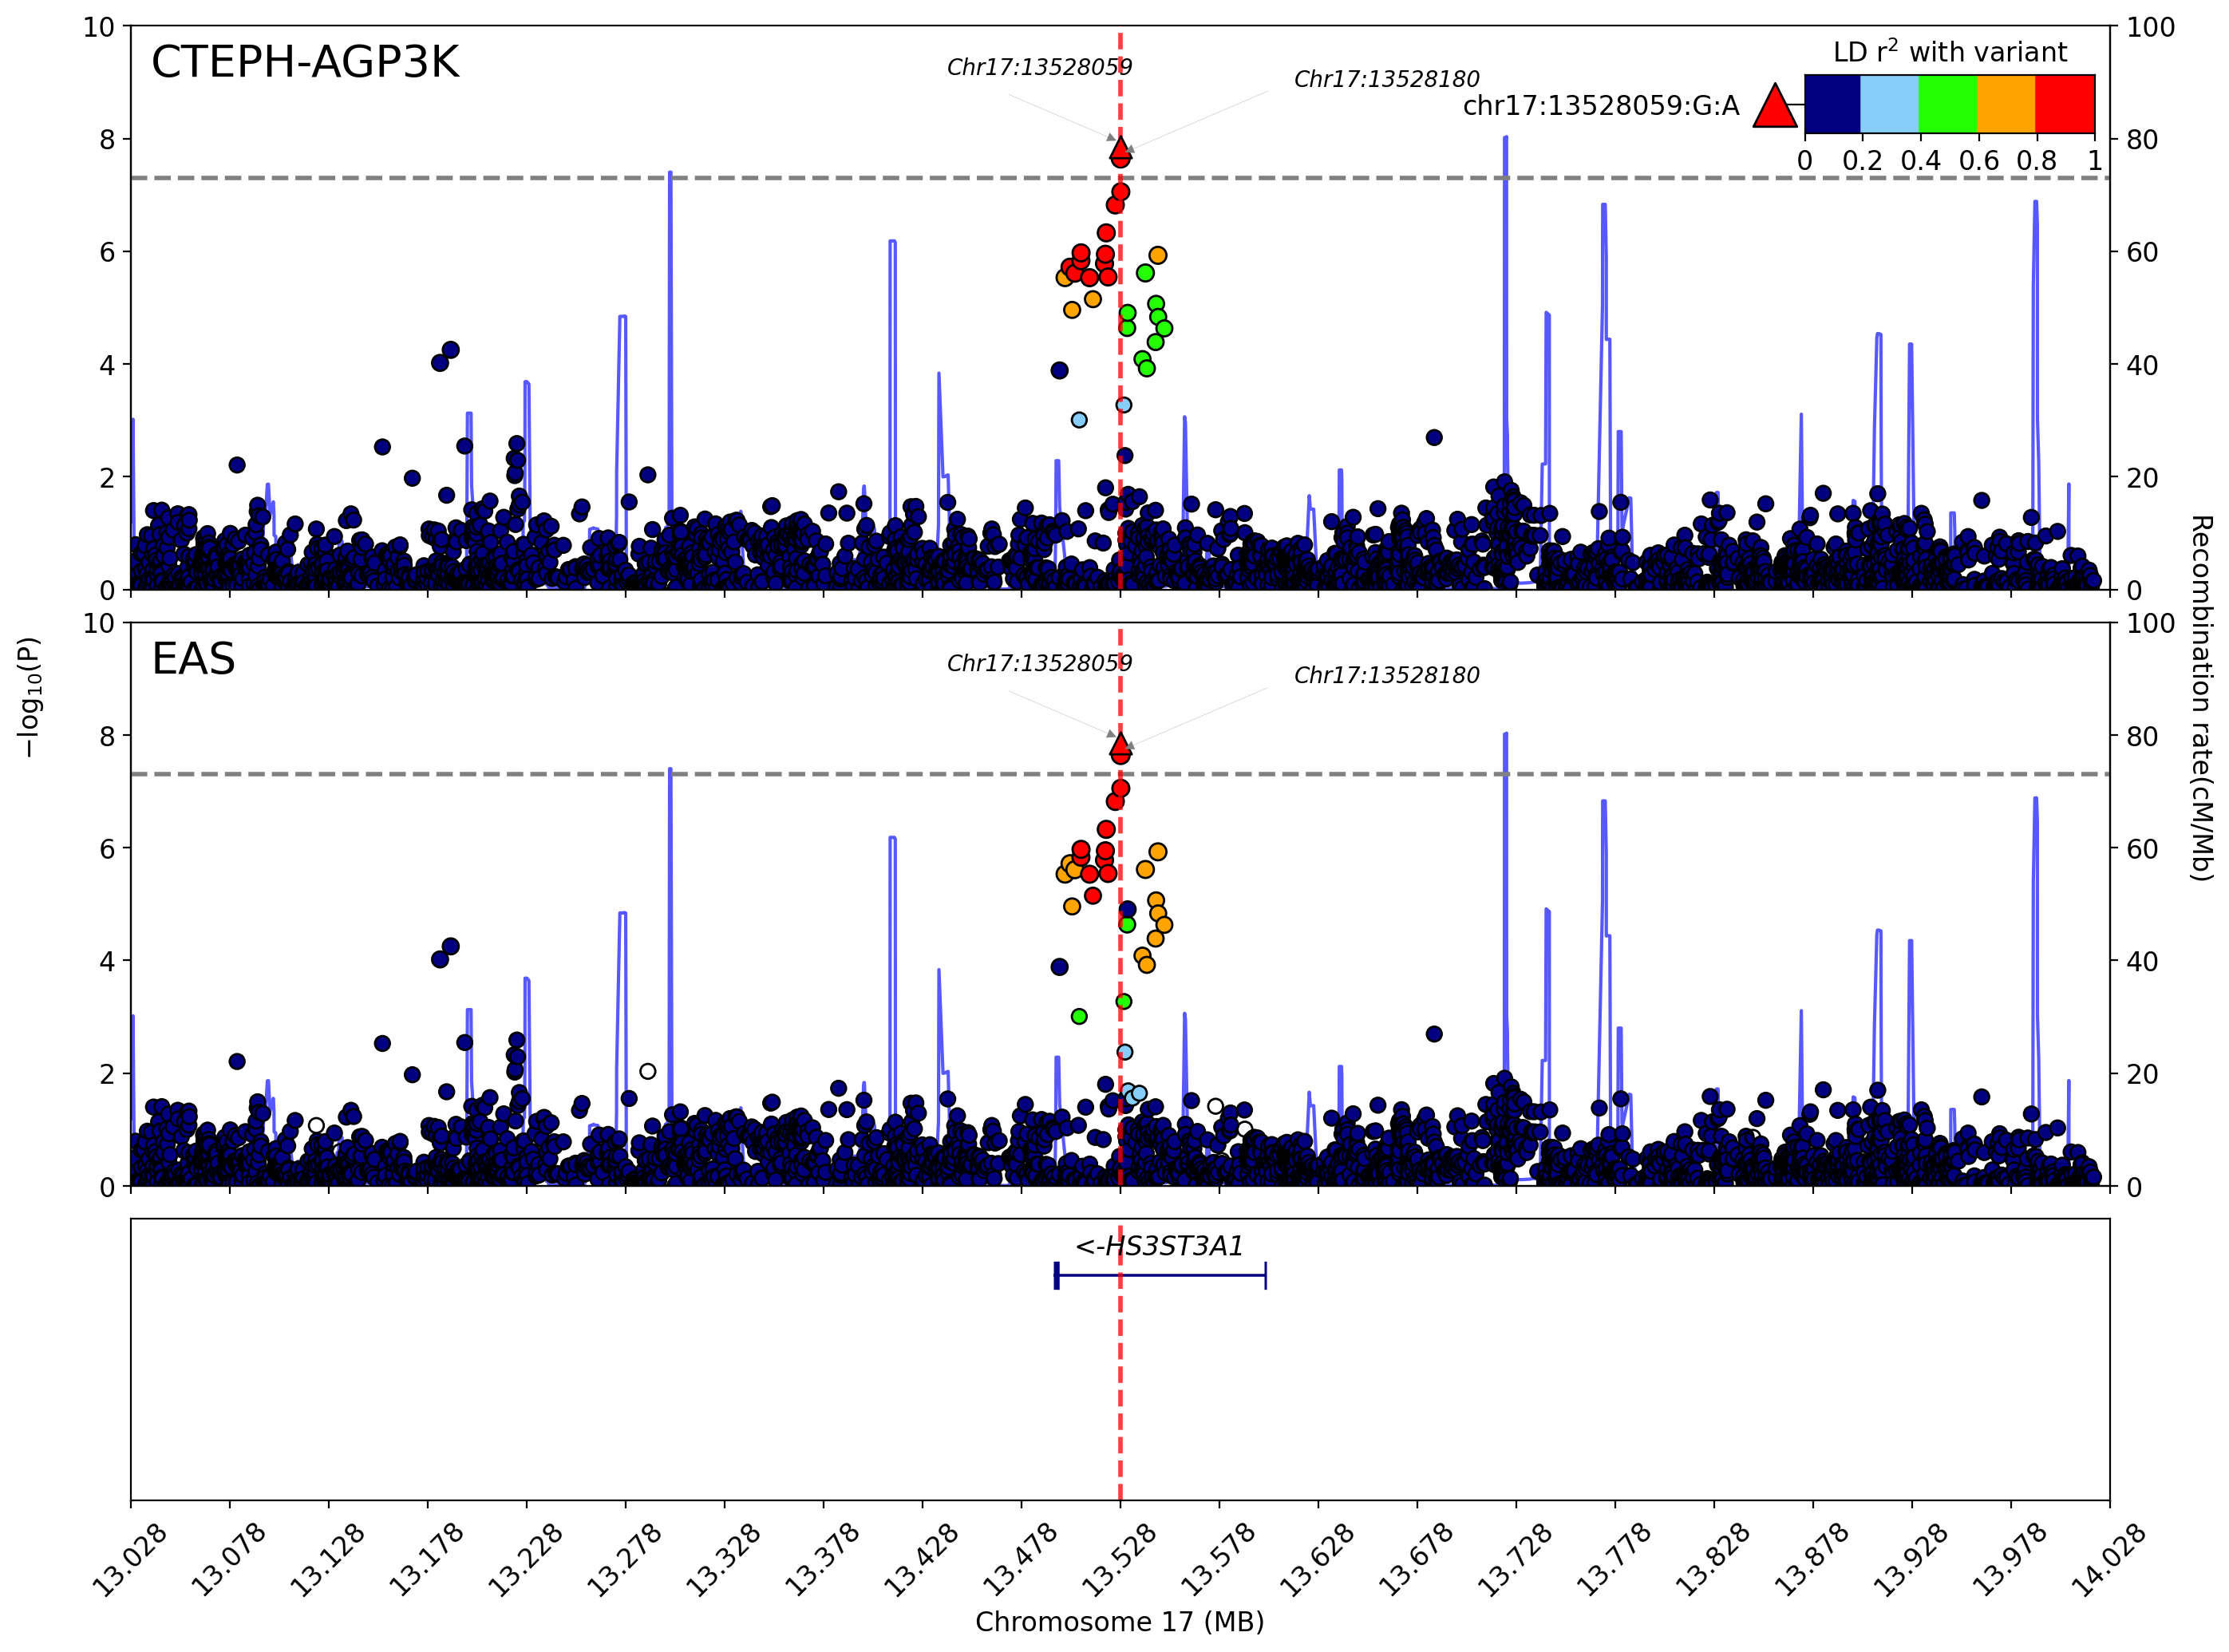

In [14]:
gl.plot_stacked_mqq(
    objects=[sumstats_add,sumstats_add],
    vcfs=[vcf_path,eas_onekg_path],
    region=(17,13028059,14028059),
    fontsize=12,
    mode="r",
    sig_level=sig_level,
    build="38",
    anno=True,
    anno_style="tight",
    anno_set=["chr17:13528059:G:A","chr17:13528180:G:A"],
    anno_args={"fontsize":10,"rotation":0},
    titles=["CTEPH-AGP3K","EAS"],
    title_args={"size":20},
    region_recombination=True,
    verbose=False, check=False
)